# Exercícios de Regressão Logística e Classificação Binária

#Exercício 1:

A Regressão Logística funciona em duas etapas:


## 1. Parte Linear

Primeiro, o modelo calcula:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

onde:

- $x_1$ e $x_2$ são as entradas (features)  
- $w_1$ e $w_2$ são os pesos  
- $b$ é o bias (ajuste)



## 2. Função Sigmoide

Depois, aplica a função sigmoide:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Isso transforma o valor em uma **probabilidade entre 0 e 1**.


## Tarefa 1

Suponha que o modelo aprendeu:

- $w_1 = 2.0$  
- $w_2 = -1.0$  
- $b = 0.5$

E temos um ponto:

- $x_1 = 1.2$  
- $x_2 = -0.3$


### a) Calcule o valor de $z$

$$
z = w_1 x_1 + w_2 x_2 + b
$$


### b) Calcule a probabilidade

$$
\hat{y} = \frac{1}{1 + e^{-z}}
$$


### c) Classificação final

- Se $\hat{y} > 0.5$ → Classe 1  
- Caso contrário → Classe 0  



## Tarefa 2

Responda com suas próprias palavras:

1. O que representam $w_1$ e $w_2$?  
2. Qual o papel do $b$?  
3. Por que usamos a função sigmoide?

Dica:

- $w$ → importância de cada variável  
- $b$ → ajuste da linha  
- Sigmoide → transforma em probabilidade  

# Exercício 2:

Neste exercício, você vai criar um código semelhante ao exemplo visto em aula para treinar um modelo de **Regressão Logística**.


# Tarefa

Implemente um classificador binário seguindo os seguintes dados:

Crie duas classes:

- Classe 0: centrada em (-2, -2)  
- Classe 1: centrada em (2, 2)  

Use distribuição normal para gerar os pontos.

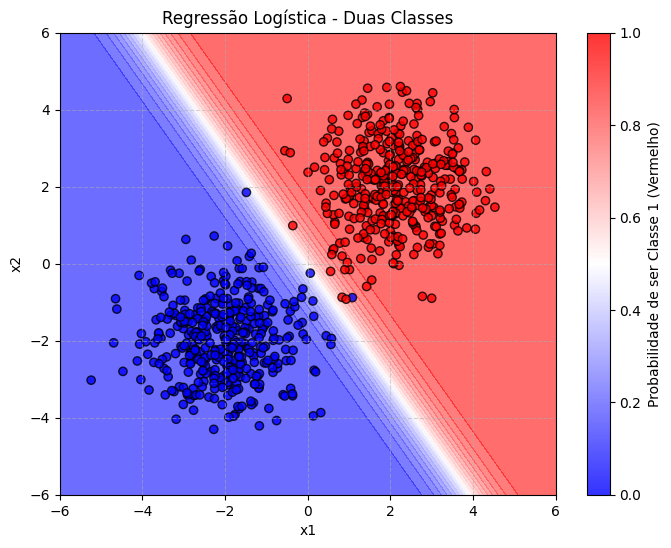

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

np.random.seed(42)

N = 400

# Classe 0 (centrada em -2, -2)
x0 = np.random.randn(N, 2) - 2
y0 = np.zeros(N)

# Classe 1 (centrada em 2, 2)
x1 = np.random.randn(N, 2) + 2
y1 = np.ones(N)

# Juntar dados
X = np.vstack([x0, x1])
Y = np.hstack([y0, y1])

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Treinar modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)

# Fronteira de decisão e Plot dos dados
xx, yy = np.meshgrid(np.linspace(-6, 6, 200), np.linspace(-6, 6, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(8,6))
# 1. Plotando a fronteira
plt.contourf(xx, yy, probs, levels=20, alpha=0.6, cmap="bwr")
# 2. Plotando os pontos reais
plt.scatter(X[:,0], X[:,1], c=Y, edgecolor="k", cmap="bwr", alpha=0.8)

plt.title("Regressão Logística - Duas Classes")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="Probabilidade de ser Classe 1 (Vermelho)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Desafio:

Simule um dataset de saúde, onde a probabilidade de risco é dada por uma função logística.

Probabilidade:

$$ p = \frac{1}{1 + e^{-(0.03 \cdot P + 0.02 \cdot C - 10)}} $$

Tarefas
* Simular 700 pacientes.
* Calcular $p$ usando a fórmula acima.
* Gerar a classe $y$.
* Treinar regressão logística.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Simular pacientes
np.random.seed(42)
N = 700

# Pressão (P) e Colesterol (C)
P = np.random.uniform(80, 200, N)   # Pressão
C = np.random.uniform(100, 300, N)  # Colesterol
X = np.column_stack((P, C))

# 2. Calcular p
# Fórmula: p = 1 / (1 + e^(-(0.03 * P + 0.02 * C - 10)))
z = (0.03 * P) + (0.02 * C) - 10
p = 1 / (1 + np.exp(-z))

# 3. Criar classes
# Risco (Classe 1) se p >= 0.5, senão Sem Risco (Classe 0)
# Famoso Threshold
y = (p >= 0.5).astype(int)

# 4. Treinar modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

print("Acurácia no dataset de saúde:", model.score(X_test, y_test))

Acurácia no dataset de saúde: 1.0
